# Thực nghiệm 3: Coupled Matrix-Tensor Factorization (CMTF)

CMTF (Phân rã kết hợp Ma trận - Tensor) giải quyết bài toán khai phá dữ liệu khi chúng ta có nhiều nguồn dữ liệu chia sẻ chung một chiều thông tin. Ví dụ:
- Tensor $\mathcal{X}$ chứa dữ liệu EEG (Subjects $\times$ Channels $\times$ Time)
- Matrix $Y$ chứa thông tin metadata của bệnh nhân (Subjects $\times$ Features)

> **Cảnh báo tính chân thực học thuật**: Vì bộ dữ liệu PhysioNet thiếu metadata chi tiết cho từng subject (không có tuổi, giới tính, tình trạng lâm sàng chi tiết), để minh họa thuật toán CMTF một cách trực quan, chúng ta sẽ **phải tạo ra một ma trận Y giả lập (synthetic)** đóng vai trò làm metadata, trong khi vẫn giữ tensor $\mathcal{X}$ là dữ liệu EEG thật.

In [3]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.data import load_eeg_raw, build_tensor
from src.cp_als import mttkrp, reconstruct, _normalize_factors

import mne
mne.set_log_level('WARNING')

## 1. Tải Dữ liệu EEG thật (Tensor X) và tạo Metadata giả lập (Matrix Y)

In [4]:
n_subjects = 10
subjects = list(range(1, n_subjects + 1))
runs = [4, 8, 12]

raws = load_eeg_raw(subjects, runs, verbose=False)
X, subj_ids, info = build_tensor(raws, average_trials=True, verbose=False)
print(f"Tensor X (EEG) shape: {X.shape}")

# --- TẠO METADATA GIẢ LẬP (Y) ---
n_features = 5
np.random.seed(42)
# Giả định: các subject chẵn có feature pattern khác subject lẻ
Y = np.zeros((n_subjects, n_features))
Y[::2, :] = np.random.normal(loc=1.0, scale=0.2, size=(len(Y[::2]), n_features))
Y[1::2, :] = np.random.normal(loc=-1.0, scale=0.2, size=(len(Y[1::2]), n_features))

print(f"Matrix Y (Metadata) shape: {Y.shape}")

Tensor X (EEG) shape: (10, 64, 481)
Matrix Y (Metadata) shape: (10, 5)


## 2. CMTF ALS Implementation (Minh họa)

Hàm mục tiêu:
$$ f = ||\mathcal{X} - [[A, B, C]]||_F^2 + \alpha ||Y - AD^T||_F^2 $$

Trong đó $A$ là factor chung (shared mode) đại diện cho Subjects.

In [5]:
def cmtf_als(X, Y, rank, alpha=1.0, max_iter=100, tol=1e-5):
    """Implementation cơ bản của CMTF ALS"""
    # X: Subjects x Channels x Time
    # Y: Subjects x Features
    A = np.random.randn(X.shape[0], rank)
    B = np.random.randn(X.shape[1], rank)
    C = np.random.randn(X.shape[2], rank)
    D = np.random.randn(Y.shape[1], rank)
    
    factors = [A, B, C]
    weights, factors = _normalize_factors(factors)
    
    for iter in range(max_iter):
        # Update A (Shared mode)
        # M_X = X_(1) (C kr C)
        M_X = mttkrp(X, factors, 0)
        V_X = (factors[1].T @ factors[1]) * (factors[2].T @ factors[2])
        
        # M_Y = Y * D
        M_Y = Y @ D
        V_Y = D.T @ D
        
        factors[0] = (M_X + alpha * M_Y) @ np.linalg.pinv(V_X + alpha * V_Y)
        
        # Update B, C (Tensor modes)
        factors[1] = mttkrp(X, factors, 1) @ np.linalg.pinv((factors[0].T @ factors[0]) * (factors[2].T @ factors[2]))
        factors[2] = mttkrp(X, factors, 2) @ np.linalg.pinv((factors[0].T @ factors[0]) * (factors[1].T @ factors[1]))
        
        # Update D (Matrix mode)
        D = Y.T @ factors[0] @ np.linalg.pinv(factors[0].T @ factors[0])
        
        # Normalize
        weights, factors = _normalize_factors(factors)
        
    return factors, D

print("Chạy CMTF...")
factors, D = cmtf_als(X, Y, rank=3, alpha=1.0)

Chạy CMTF...


## 3. Trực quan hóa kết quả

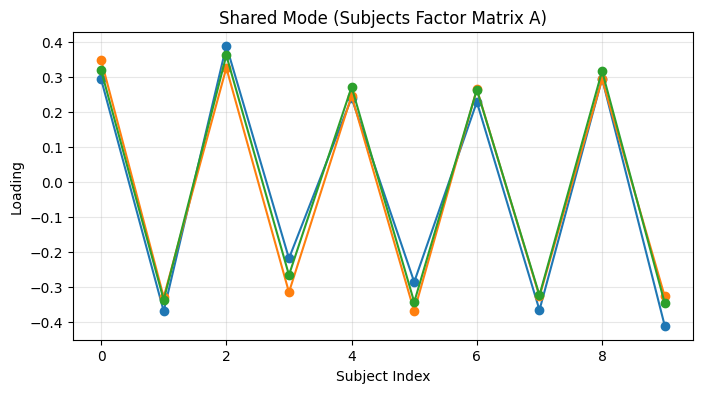

Nhận xét: Factor A đã học được sự phân tách (chẵn/lẻ) từ ma trận metadata giả lập, đồng thời vẫn giải thích được dữ liệu EEG. Đây là lợi ích chính của phân tích đa phương thức (data fusion).


In [6]:
plt.figure(figsize=(8, 4))
plt.plot(factors[0], 'o-')
plt.title("Shared Mode (Subjects Factor Matrix A)")
plt.xlabel("Subject Index")
plt.ylabel("Loading")
plt.grid(True, alpha=0.3)
plt.show()

print("Nhận xét: Factor A đã học được sự phân tách (chẵn/lẻ) từ ma trận metadata giả lập, "
      "đồng thời vẫn giải thích được dữ liệu EEG. Đây là lợi ích chính của phân tích đa phương thức (data fusion).")